# Data Collection

In [2]:
#imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from scipy.stats import skew, probplot

# Load Datasets

In [11]:
# Load Datasets

ratings_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.ratings.tsv', delimiter='\t', low_memory=False)
title_basics_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.basics.tsv', delimiter='\t', low_memory=False, dtype={"runtimeMinutes": str})
name_basics_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/name.basics.tsv', delimiter='\t', low_memory=False)
akas_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.akas.tsv', delimiter='\t', low_memory=False)
crew_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.crew.tsv', delimiter='\t', low_memory=False)
principals_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.principals.tsv', delimiter='\t', low_memory=False)
tmdb_movies_dataframe = pd.read_csv('/kaggle/input/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv', low_memory=False)
iso2_to_iso3_dataframe = pd.read_csv('/kaggle/input/country-codes-alpha2-alpha3/Country Codes Alpha-2 Alpha-3.csv', low_memory=False)

# Data Pre-Processing

In [36]:
# Drop columns in basics dataframe
title_basics_dataframe = title_basics_dataframe.drop(columns=[
    'primaryTitle', 'titleType', 'originalTitle', 'endYear'
])

# Drop columns in TMDB movies dataframe
tmdb_movies_dataframe = tmdb_movies_dataframe.drop(columns=[
    'adult', 'status', 'poster_path', 'backdrop_path', 'homepage', 'original_title', 'overview', 'genres'
])

#Drop columns in Name basics dataframe
name_basics_dataframe = name_basics_dataframe.drop(columns=[
    'birthYear', 'deathYear'
])

#Drop columns in Crew dataframe
crew_dataframe = crew_dataframe.drop(columns=[
    'writers'
])

#Drop columns in akas dataframe
akas_dataframe = akas_dataframe.drop(columns=[
    'isOriginalTitle', 'attributes', 'types'
])

#Drop columns in principals dataframe
principals_dataframe = principals_dataframe.drop(columns=[
    'characters', 'job', 'ordering'
])

#Drop columns in iso2_to_iso3_dataframe dataframe
iso2_to_iso3_dataframe = iso2_to_iso3_dataframe.drop(columns=[
    'numeric'
])

KeyError: "['isOriginalTitle', 'attributes', 'types'] not found in axis"

# Merge IMDB Title Basics and TMDB Datasets

## Handling missing and irrelevant data

In [13]:
# process_movie_data function
def process_movie_data(title_basics_dataframe, tmdb_movies_dataframe):
    # Verify DataFrames are loaded correctly
    if title_basics_dataframe is None or tmdb_movies_dataframe is None:
        raise ValueError("One or both DataFrames are not loaded properly.")

    # Clean and preprocess basics dataframe
    if "runtimeMinutes" in title_basics_dataframe.columns:
        title_basics_dataframe["runtimeMinutes"] = title_basics_dataframe["runtimeMinutes"].replace("\\N", pd.NA)
        title_basics_dataframe["runtimeMinutes"] = pd.to_numeric(title_basics_dataframe["runtimeMinutes"], errors="coerce")
        title_basics_dataframe = title_basics_dataframe.dropna(subset=["runtimeMinutes"])

    # Clean and preprocess TMDB dataframe
    if "revenue" in tmdb_movies_dataframe.columns:
        tmdb_movies_dataframe["revenue"] = pd.to_numeric(tmdb_movies_dataframe["revenue"], errors="coerce")
        tmdb_movies_dataframe = tmdb_movies_dataframe.dropna(subset=["runtime", "revenue"])
        tmdb_movies_dataframe = tmdb_movies_dataframe[tmdb_movies_dataframe["revenue"] > 0]

    # Merge datasets
    movies_data = tmdb_movies_dataframe.merge(title_basics_dataframe, left_on="imdb_id", right_on="tconst", how="inner")
    

    return movies_data

## Handling Skewness and Outliers

Skewness before removing outliers:
Runtime: 0.79
Revenue: 7.31
Budget: 4.18
Vote Count: 5.12
Vote Average: -1.81


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

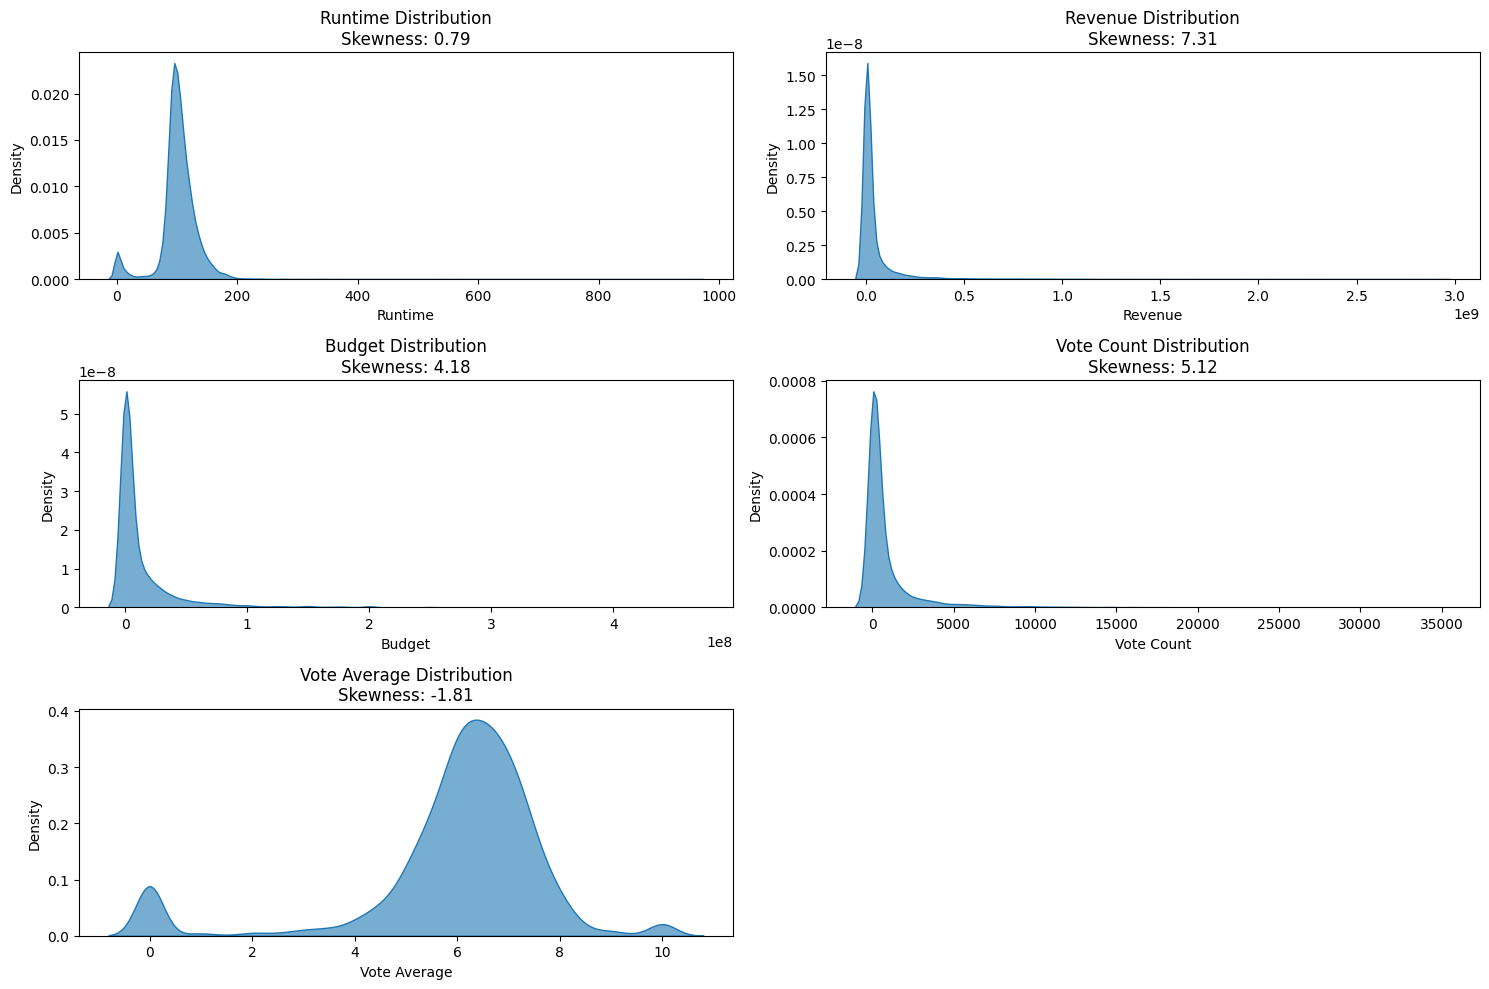


Skewness after removing outliers:
Runtime: 0.14
Revenue: 2.17
Budget: 3.73
Vote Count: 6.51
Vote Average: -1.89


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

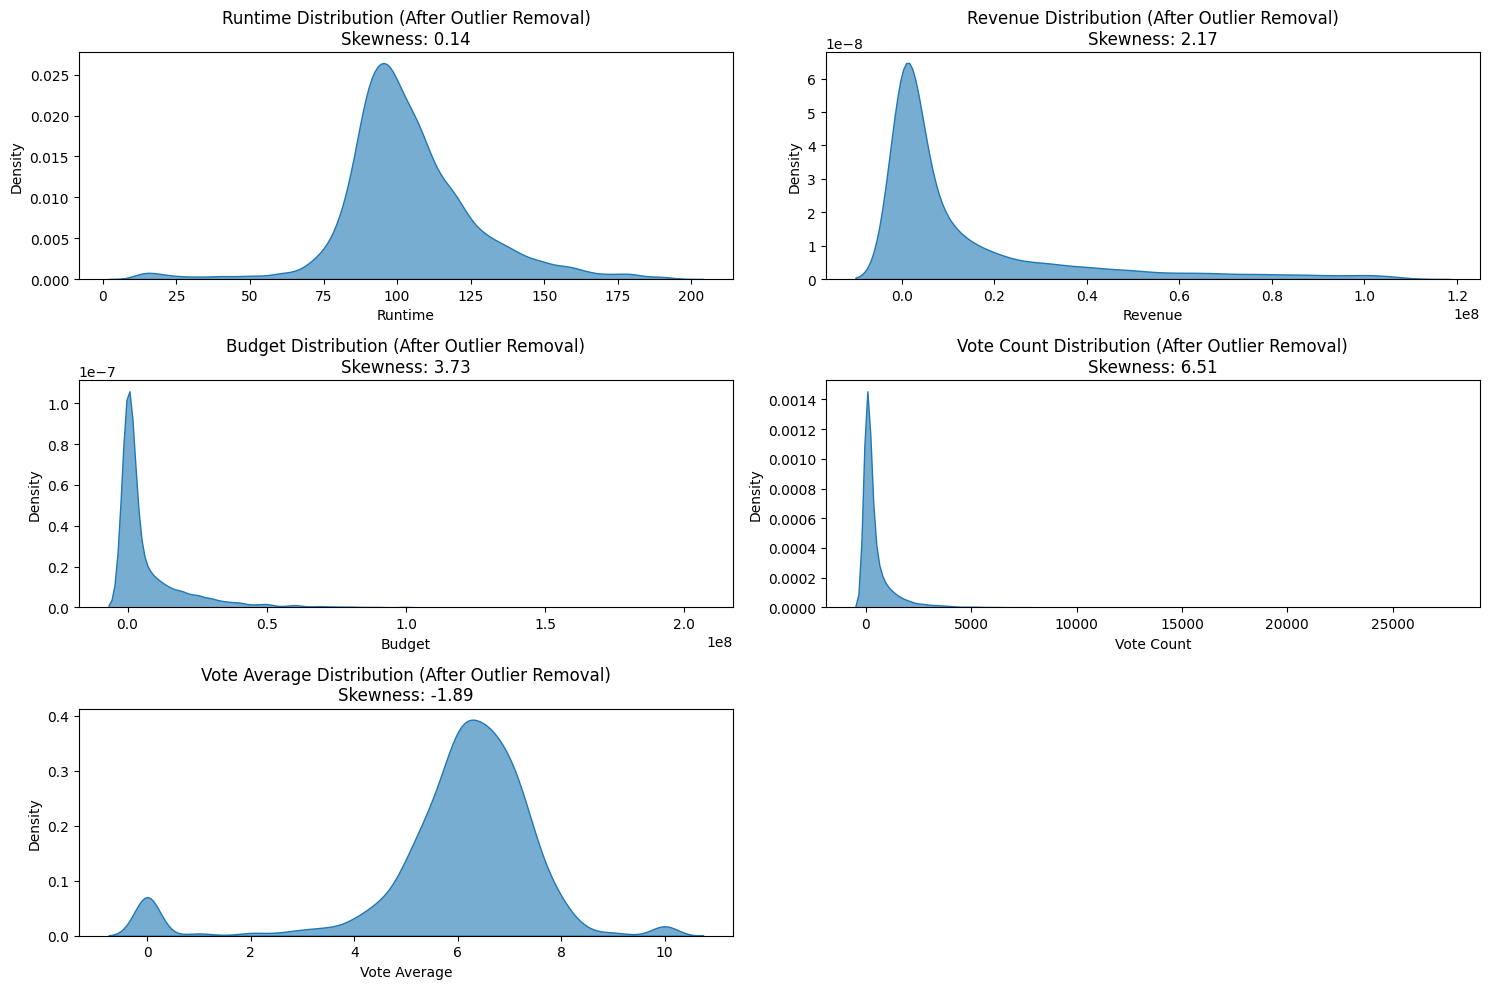

In [14]:
# movies data
movies_data = process_movie_data(title_basics_dataframe, tmdb_movies_dataframe)

# Replace Inf values with NaN to avoid warnings
for col in ["runtime", "revenue", "budget", "vote_count", "vote_average"]:
    if col in movies_data.columns:
        movies_data[col] = movies_data[col].replace([np.inf, -np.inf], np.nan)

# Drop rows with NaN values to ensure clean data before plotting
movies_data = movies_data.dropna(subset=["runtime", "revenue", "budget", "vote_count", "vote_average"], how="any")

# Compute skewness for multiple numerical columns
skewness_values = {
    "Runtime": skew(movies_data["runtime"], nan_policy='omit'),
    "Revenue": skew(movies_data["revenue"], nan_policy='omit'),
    "Budget": skew(movies_data["budget"], nan_policy='omit'),
    "Vote Count": skew(movies_data["vote_count"], nan_policy='omit'),
    "Vote Average": skew(movies_data["vote_average"], nan_policy='omit')
}

# Print skewness values
print("Skewness before removing outliers:")
for feature, value in skewness_values.items():
    print(f"{feature}: {value:.2f}")

# Density (KDE) plots for each feature before outlier removal
plt.figure(figsize=(15, 10))
for i, (feature, value) in enumerate(skewness_values.items()):
    plt.subplot(3, 2, i + 1)
    sns.kdeplot(movies_data[feature.lower().replace(" ", "_")], fill=True, alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(f"{feature} Distribution\nSkewness: {value:.2f}")

plt.tight_layout()
plt.show()

# Remove outliers using IQR but with more relaxed thresholds
Q1_runtime = movies_data["runtime"].quantile(0.25)
Q3_runtime = movies_data["runtime"].quantile(0.75)
IQR_runtime = Q3_runtime - Q1_runtime

Q1_revenue = movies_data["revenue"].quantile(0.25)
Q3_revenue = movies_data["revenue"].quantile(0.75)
IQR_revenue = Q3_revenue - Q1_revenue

movies_data = movies_data[
    (movies_data["runtime"] >= (Q1_runtime - 3 * IQR_runtime)) & 
    (movies_data["runtime"] <= (Q3_runtime + 3 * IQR_runtime)) &
    (movies_data["revenue"] >= (Q1_revenue - 3 * IQR_revenue)) & 
    (movies_data["revenue"] <= (Q3_revenue + 3 * IQR_revenue))
]

# Compute skewness again after removing outliers
skewness_values_after = {
    "Runtime": skew(movies_data["runtime"], nan_policy='omit'),
    "Revenue": skew(movies_data["revenue"], nan_policy='omit'),
    "Budget": skew(movies_data["budget"], nan_policy='omit'),
    "Vote Count": skew(movies_data["vote_count"], nan_policy='omit'),
    "Vote Average": skew(movies_data["vote_average"], nan_policy='omit')
}

# Print skewness values after removing outliers
print("\nSkewness after removing outliers:")
for feature, value in skewness_values_after.items():
    print(f"{feature}: {value:.2f}")

# Density (KDE) plots after outlier removal
plt.figure(figsize=(15, 10))
for i, (feature, value) in enumerate(skewness_values_after.items()):
    plt.subplot(3, 2, i + 1)
    sns.kdeplot(movies_data[feature.lower().replace(" ", "_")], fill=True, alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(f"{feature} Distribution (After Outlier Removal)\nSkewness: {value:.2f}")

plt.tight_layout()
plt.show()



## Handling EDA (Scatter Plot)

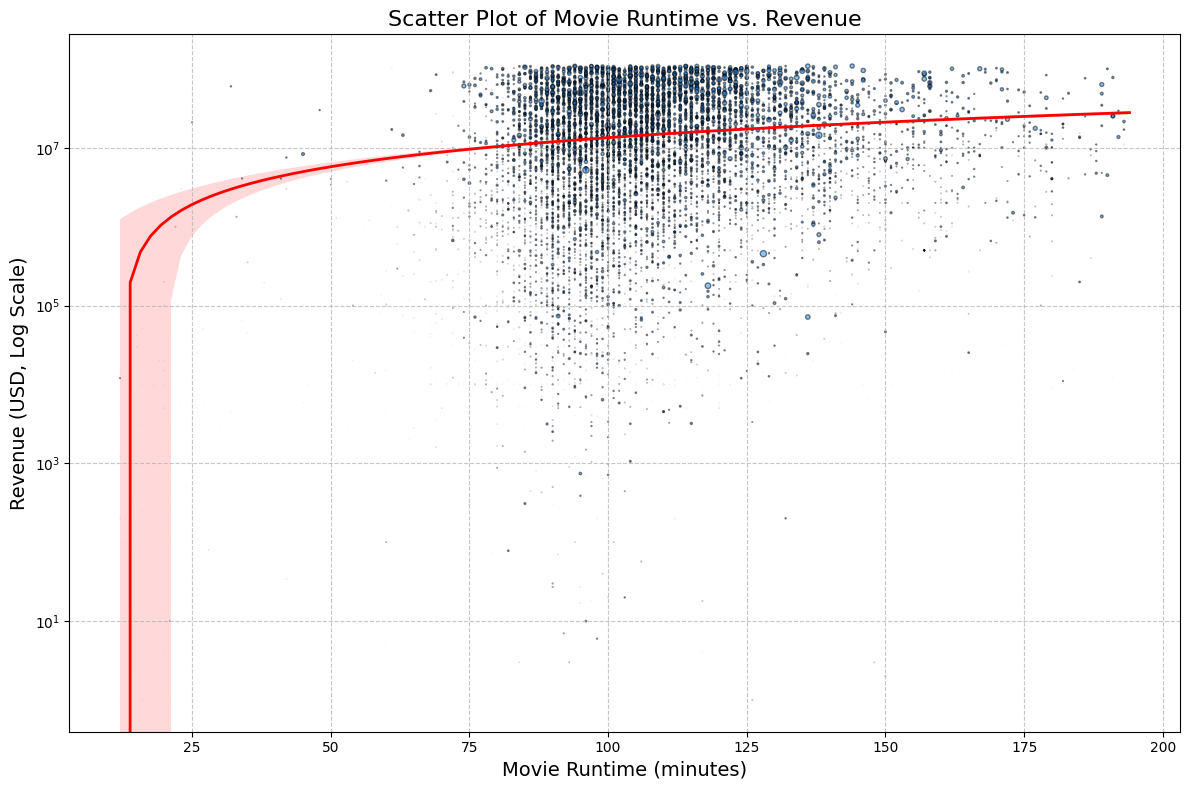

In [16]:
plt.figure(figsize=(12, 8))

# Scatter plot with size variation (scaled by budget)
scatter = plt.scatter(
    movies_data["runtime"], movies_data["revenue"], 
    s=movies_data["budget"] / 1e7 if "budget" in movies_data else 50,  # Adjust size if budget exists
    color='dodgerblue', alpha=0.5, edgecolors='k'
)

# Format y-axis for better readability
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# Apply log scale for revenue if values span a wide range
plt.yscale('log')

# Trend line (Linear Regression)
sns.regplot(
    x="runtime", y="revenue", data=movies_data, 
    scatter=False, color='red', line_kws={'linewidth': 2}
)

# Labels and title
plt.xlabel("Movie Runtime (minutes)", fontsize=14)
plt.ylabel("Revenue (USD, Log Scale)", fontsize=14)
plt.title("Scatter Plot of Movie Runtime vs. Revenue", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Comparative Analysis of Adult vs. Family Movies

## Handling Outiers

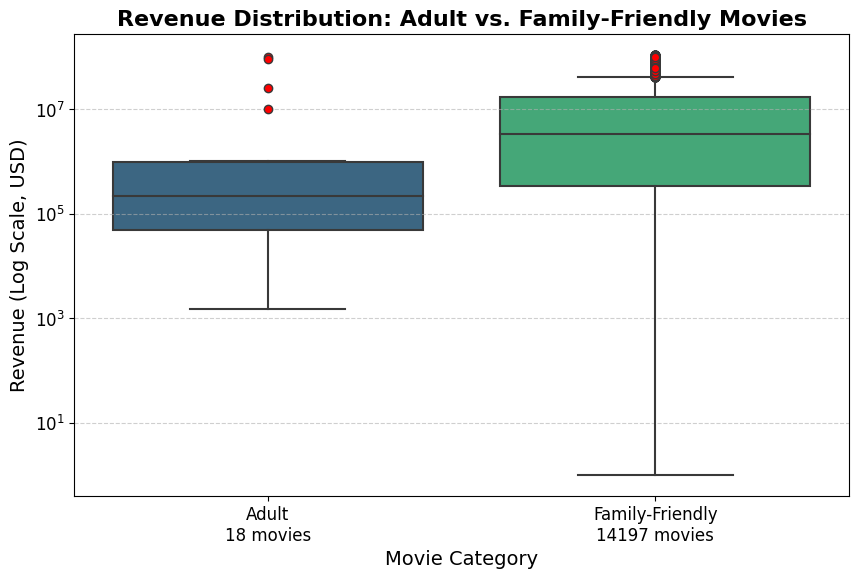

In [17]:
# movies data
movies_data = process_movie_data(title_basics_dataframe, tmdb_movies_dataframe)

# Convert 'isAdult' column to integer type
movies_data["isAdult"] = pd.to_numeric(movies_data["isAdult"], errors="coerce")

# Define categories
movies_data["Category"] = movies_data["isAdult"].apply(lambda x: "Adult" if x == 1 else "Family-Friendly")

# Remove outliers using IQR
Q1_runtime, Q3_runtime = movies_data["runtime"].quantile([0.25, 0.75])
IQR_runtime = Q3_runtime - Q1_runtime
Q1_revenue, Q3_revenue = movies_data["revenue"].quantile([0.25, 0.75])
IQR_revenue = Q3_revenue - Q1_revenue

movies_data = movies_data[
    (movies_data["runtime"] >= (Q1_runtime - 3 * IQR_runtime)) & 
    (movies_data["runtime"] <= (Q3_runtime + 3 * IQR_runtime)) &
    (movies_data["revenue"] >= (Q1_revenue - 3 * IQR_revenue)) & 
    (movies_data["revenue"] <= (Q3_revenue + 3 * IQR_revenue))
]

# Sort categories by median revenue for better readability
sorted_categories = movies_data.groupby("Category")["revenue"].median().sort_values().index

# Count number of movies per category
category_counts = movies_data["Category"].value_counts()

## Handling EDA (Box plot)

In [ ]:
# Create Box Plot
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    x="Category", y="revenue", data=movies_data, palette="viridis", order=sorted_categories,
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 6}
)

# Modify x-axis labels to include movie counts
labels = [f"{cat}\n{category_counts[cat]} movies" for cat in sorted_categories]
ax.set_xticklabels(labels, fontsize=12)

# Title & Labels
plt.title("Revenue Distribution: Adult vs. Family-Friendly Movies", fontsize=16, fontweight='bold')
plt.ylabel("Revenue (Log Scale, USD)", fontsize=14)
plt.xlabel("Movie Category", fontsize=14)
plt.yticks(fontsize=12)
plt.yscale("log")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# Movie Director influence on movie revenue and ratings

## Handling missing data and Outliers

In [18]:
# Data Cleaning
## IMDB Crew Dataset
crew_dataframe = crew_dataframe.dropna(subset=['directors'])  # Drop rows with missing directors
crew_dataframe = crew_dataframe.explode('directors')  # Split multiple directors into separate rows

## TMDB Movies Dataset
tmdb_movies_dataframe['revenue'] = tmdb_movies_dataframe['revenue'].replace(0, np.nan)  # Replace 0 revenues with NaN
tmdb_movies_dataframe['vote_average'] = tmdb_movies_dataframe['vote_average'].replace(0, np.nan)
tmdb_movies_dataframe = tmdb_movies_dataframe.dropna(subset=['revenue', 'vote_average'])  # Drop missing values

# Function to plot Q-Q plot and calculate skewness
def plot_qq_skewness(df, columns):
    fig, axes = plt.subplots(1, len(columns), figsize=(12, 6))  # Create subplots

    for i, column in enumerate(columns):
        stats.probplot(df[column].dropna(), dist="norm", plot=axes[i])  # Q-Q plot
        axes[i].set_title(f'Q-Q Plot of {column}')
        axes[i].set_xlabel("Theoretical Quantiles")
        axes[i].set_ylabel("Sample Quantiles")

        # Calculate and print skewness
        skew_value = skew(df[column].dropna())
        print(f'Skewness of {column}: {skew_value}')

    plt.tight_layout()
    plt.show()

# Remove outliers using Z-score
for col in ['revenue', 'vote_average']:
    tmdb_movies_dataframe = tmdb_movies_dataframe[(np.abs((tmdb_movies_dataframe[col] - tmdb_movies_dataframe[col].mean()) / tmdb_movies_dataframe[col].std()) < 3)]

# IQR method to remove outliers
for col in ['revenue', 'vote_average']:
    Q1 = tmdb_movies_dataframe[col].quantile(0.25)
    Q3 = tmdb_movies_dataframe[col].quantile(0.75)
    IQR = Q3 - Q1
    # Remove rows where values are outside the IQR range
    tmdb_movies_dataframe = tmdb_movies_dataframe[(tmdb_movies_dataframe[col] >= (Q1 - 1.5 * IQR)) & (tmdb_movies_dataframe[col] <= (Q3 + 1.5 * IQR))]

# Normalize revenue and vote_average
tmdb_movies_dataframe['revenue'] = (tmdb_movies_dataframe['revenue'] - tmdb_movies_dataframe['revenue'].min()) / (tmdb_movies_dataframe['revenue'].max() - tmdb_movies_dataframe['revenue'].min())
tmdb_movies_dataframe['vote_average'] = (tmdb_movies_dataframe['vote_average'] - tmdb_movies_dataframe['vote_average'].min()) / (tmdb_movies_dataframe['vote_average'].max() - tmdb_movies_dataframe['vote_average'].min())

# Merge Datasets
crew_movies = pd.merge(crew_dataframe, tmdb_movies_dataframe, left_on='tconst', right_on='imdb_id', how='inner')
director_data = pd.merge(crew_movies, name_basics_dataframe, left_on='directors', right_on='nconst', how='inner')

## Handling Skewness

Skewness of revenue: 1.8180194881317353
Skewness of vote_average: 0.005558627165782504


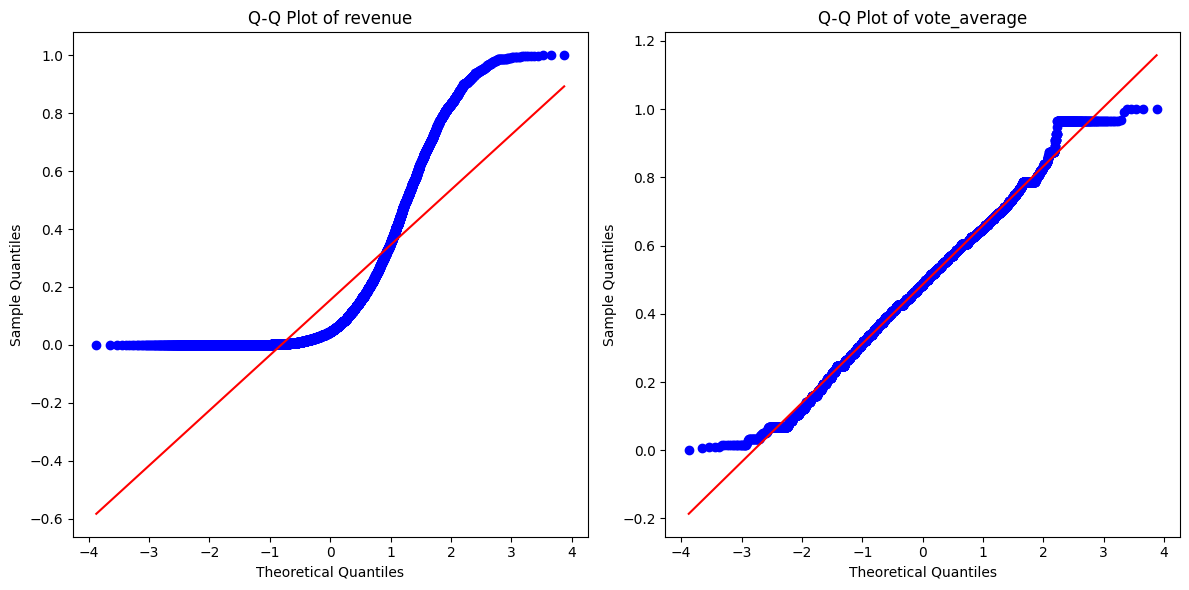

In [19]:
plot_qq_skewness(tmdb_movies_dataframe, ['revenue', 'vote_average'])

## Handling EDA (Bar plots)

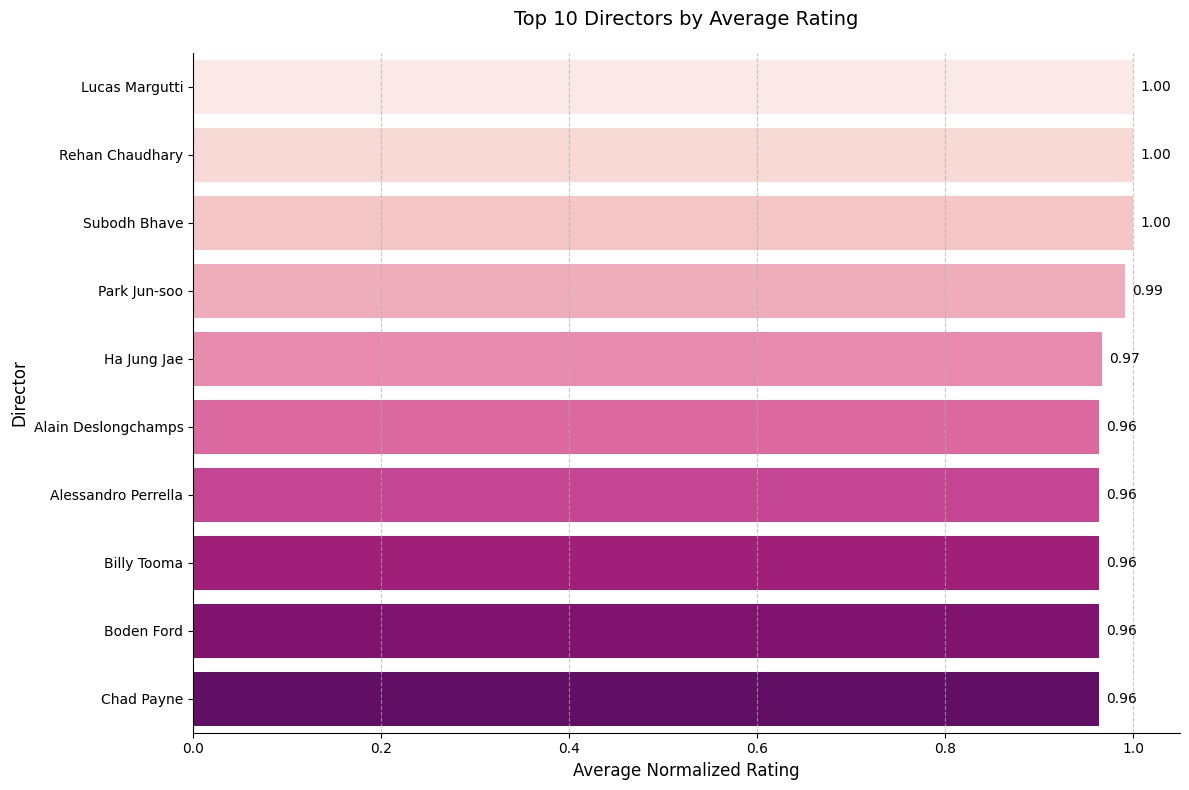

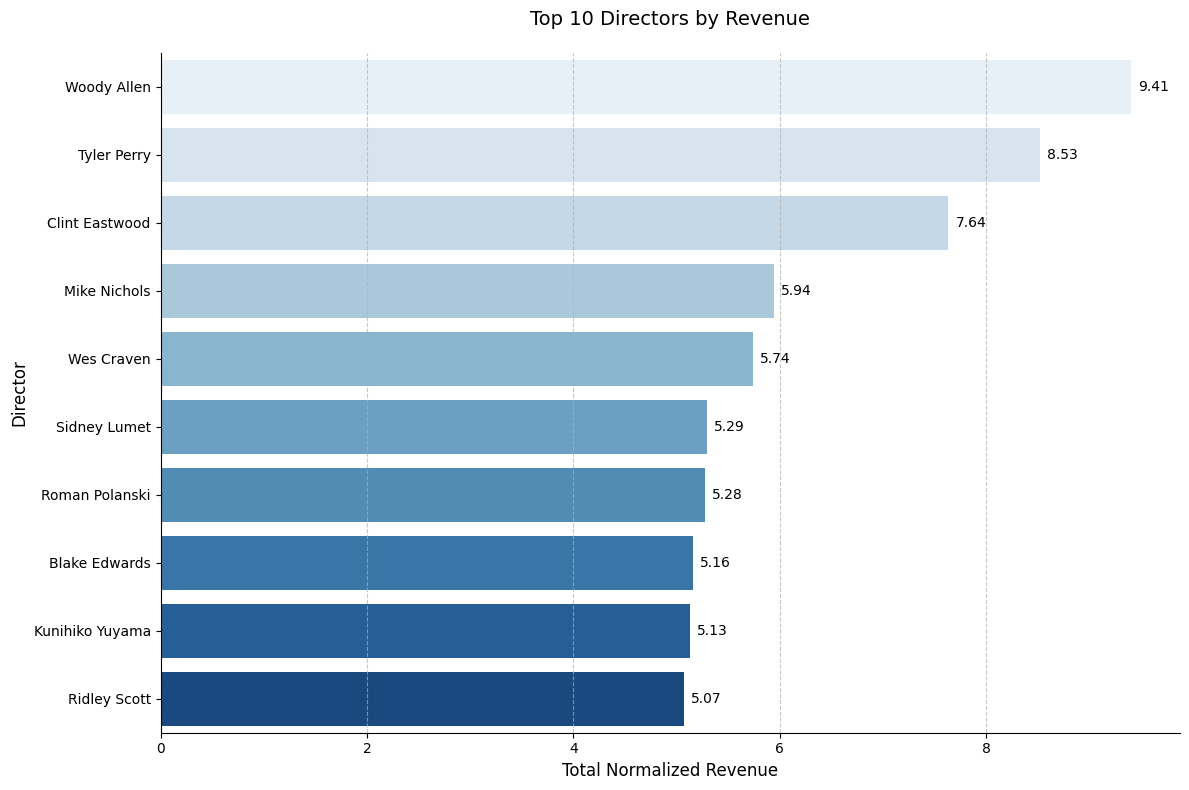

In [20]:
# Aggregate revenue and rating per director
director_stats = director_data.groupby('primaryName').agg({'revenue': 'sum', 'vote_average': 'mean'}).reset_index()

# Top 10 Directors by Revenue
top_revenue_directors = director_stats.nlargest(10, 'revenue')

# Top 10 Directors by Rating
top_rating_directors = director_stats.nlargest(10, 'vote_average')

def create_enhanced_bar_plot(data, x_col, y_col, title, xlabel, color_palette):
    plt.figure(figsize=(12, 8))
    
    # Create the bar plot
    ax = sns.barplot(
        x=x_col,
        y=y_col,
        data=data,
        palette=color_palette
    )
    
    # Customize the plot
    plt.title(title, fontsize=14, pad=20)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Director", fontsize=12)
    
    # Add gridlines
    plt.grid(True, axis='x', linestyle='--', alpha=0.7)
    
    # Add value labels on the bars
    for i in ax.containers:
        ax.bar_label(i, fmt='%.2f', padding=5)
    
    # Customize the spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Adjust layout
    plt.tight_layout()

# Create color palettes
rating_colors = sns.color_palette("RdPu", n_colors=10)
revenue_colors = sns.color_palette("Blues", n_colors=10)

#Plot for Top 10 Directors by Average Rating
create_enhanced_bar_plot(
    top_rating_directors,
    'vote_average',
    'primaryName',
    "Top 10 Directors by Average Rating",
    "Average Normalized Rating",
    rating_colors
)

# Plot for Top 10 Directors by Revenue
create_enhanced_bar_plot(
    top_revenue_directors,
    'revenue',
    'primaryName',
    "Top 10 Directors by Revenue",
    "Total Normalized Revenue",
    revenue_colors
)

plt.show()

# Actor Influence on Revenue

## Handling missing and outliers data 

In [21]:
# Clean TMDB Movies Dataset
tmdb_movies_dataframe = tmdb_movies_dataframe[tmdb_movies_dataframe['revenue'] > 0]  # Keep only revenue > 0
tmdb_movies_dataframe['budget'] = tmdb_movies_dataframe['budget'].fillna(tmdb_movies_dataframe['budget'].median())
tmdb_movies_dataframe['runtime'] = tmdb_movies_dataframe['runtime'].fillna(tmdb_movies_dataframe['runtime'].median())

# Implement IQR for outlier removal
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply IQR filtering
tmdb_movies_dataframe = remove_outliers_iqr(tmdb_movies_dataframe, 'budget')
tmdb_movies_dataframe = remove_outliers_iqr(tmdb_movies_dataframe, 'runtime')
tmdb_movies_dataframe = remove_outliers_iqr(tmdb_movies_dataframe, 'revenue')

# Normalize popularity and vote counts (optional, if distribution is skewed)
tmdb_movies_dataframe['popularity'] = (tmdb_movies_dataframe['popularity'] - tmdb_movies_dataframe['popularity'].mean()) / tmdb_movies_dataframe['popularity'].std()
tmdb_movies_dataframe['vote_count'] = (tmdb_movies_dataframe['vote_count'] - tmdb_movies_dataframe['vote_count'].mean()) / tmdb_movies_dataframe['vote_count'].std()

# Filter IMDB Principals to only actors
actors_principals = principals_dataframe[principals_dataframe['category'].isin(['actor', 'actress'])]

# Merge actor names
actors_principals = actors_principals.merge(name_basics_dataframe[['nconst', 'primaryName']], on='nconst', how='left')

# Merge with TMDB movies
merged_data = actors_principals.merge(tmdb_movies_dataframe, left_on='tconst', right_on='imdb_id', how='inner')

## Handling EDA (Box and Bar Plots)

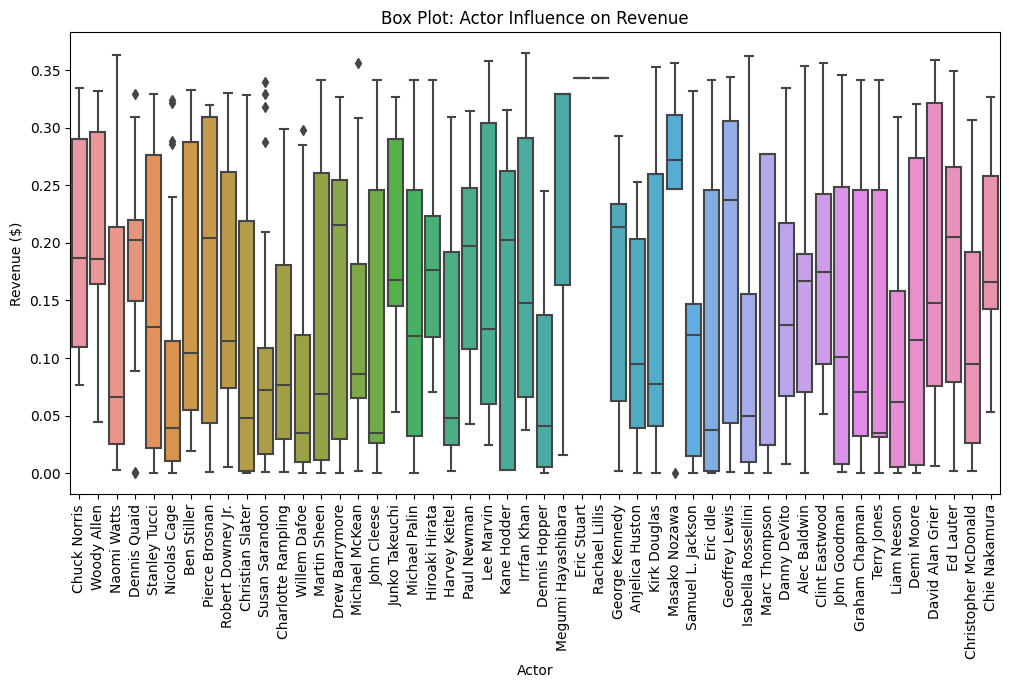

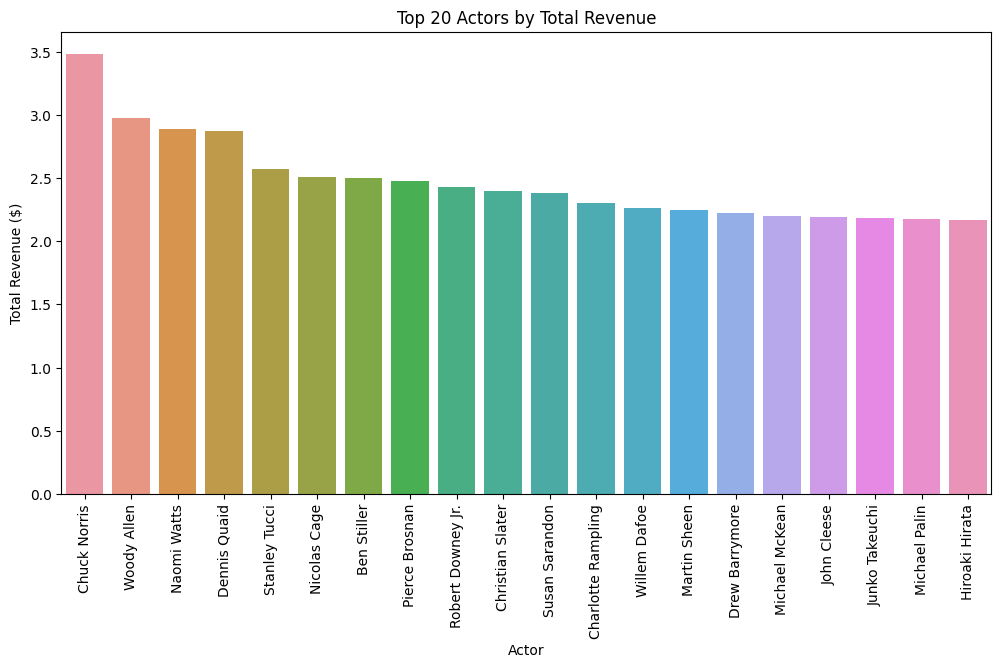

In [22]:
# Group by actor to get total revenue per actor
top_actors = merged_data.groupby('primaryName')['revenue'].sum().reset_index()
top_actors = top_actors.sort_values(by='revenue', ascending=False).head(50)
top_actors_20 = top_actors.head(20)

# Box plot - Top 50 Actor vs. Revenue
plt.figure(figsize=(12, 6))
sns.boxplot(x='primaryName', y='revenue', data=merged_data, order=top_actors['primaryName'])
plt.xticks(rotation=90)
plt.xlabel("Actor")
plt.ylabel("Revenue ($)")
plt.title("Box Plot: Actor Influence on Revenue")
plt.show()


# Bar Graph - Top 20 Actors by Revenue
plt.figure(figsize=(12, 6))
sns.barplot(x=top_actors_20['primaryName'], y=top_actors_20['revenue'])
plt.xticks(rotation=90)
plt.xlabel("Actor")
plt.ylabel("Total Revenue ($)")
plt.title("Top 20 Actors by Total Revenue")
plt.show()


# Impact of Language and Region on Revenue

## Handling missing data and outliers

In [23]:
# Handle missing values
# Drop rows where revenue is 0 or missing
tmdb_movies_dataframe = tmdb_movies_dataframe[tmdb_movies_dataframe['revenue'] > 0]
# Median imputation for budget and runtime
tmdb_movies_dataframe['budget'] = tmdb_movies_dataframe['budget'].fillna(tmdb_movies_dataframe['budget'].median())
tmdb_movies_dataframe['runtime'] = tmdb_movies_dataframe['runtime'].fillna(tmdb_movies_dataframe['runtime'].median())
# Drop missing values for language and region
akas_dataframe = akas_dataframe.dropna(subset=['region', 'language'])

# Apply IQR method to remove outliers in revenue
Q1 = tmdb_movies_dataframe['revenue'].quantile(0.25)
Q3 = tmdb_movies_dataframe['revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
tmdb_movies_dataframe = tmdb_movies_dataframe[(tmdb_movies_dataframe['revenue'] >= lower_bound) & (tmdb_movies_dataframe['revenue'] <= upper_bound)]

# Convert region codes from ISO2 to ISO3
iso_dict = dict(zip(iso2_to_iso3_dataframe['alpha2'], iso2_to_iso3_dataframe['alpha3']))
akas_dataframe['region_iso3'] = akas_dataframe['region'].map(iso_dict)

# Merge datasets on IMDb ID
tmdb_akas = tmdb_movies_dataframe.merge(akas_dataframe, left_on='imdb_id', right_on='titleId', how='left')

# Drop rows with missing region after merge
tmdb_akas = tmdb_akas.dropna(subset=['region_iso3'])

## Handling EDA (Choropleth plot)

In [24]:
# Grouping revenue by language and region
lang_revenue = tmdb_akas.groupby('language')['revenue'].mean().reset_index()
lang_revenue['language'] = lang_revenue['language'].str.upper()
region_revenue = tmdb_akas.groupby('region_iso3')['revenue'].sum().reset_index()

# Choropleth Map: Revenue by Region
fig = px.choropleth(
    region_revenue, 
    locations='region_iso3', 
    locationmode='ISO-3', 
    color='revenue', 
    title='Total Revenue by Region',
    color_continuous_scale='viridis'
)

# Improve the map appearance
fig.update_geos(
    showcoastlines=True,
    coastlinecolor="Black",
    showframe=False,
    showland=True,
    landcolor='lightgray'
)

# Update layout
fig.update_layout(
    geo=dict(
        resolution=50,
        showframe=False,
        showcoastlines=True,
        coastlinecolor='Black',
        landcolor='lightgray',
        bgcolor='white',
        projection_type='natural earth',
        showland=True,
        showlakes=True,
        lakecolor='lightblue'
    )
)

fig.show()

## Handling EDA (Bar plots)

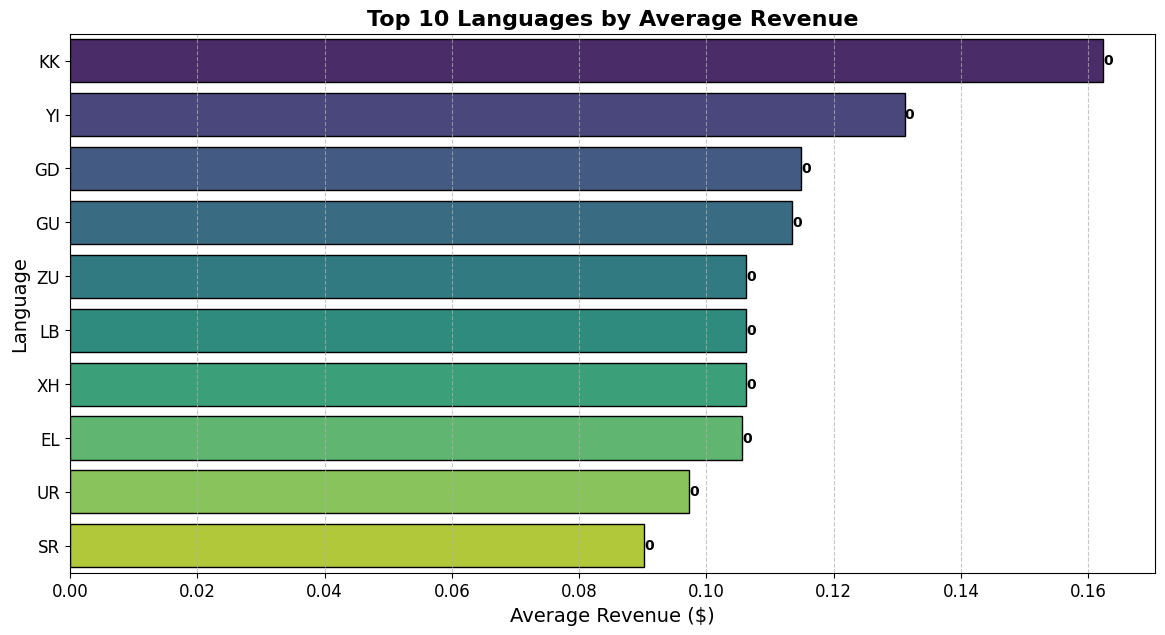

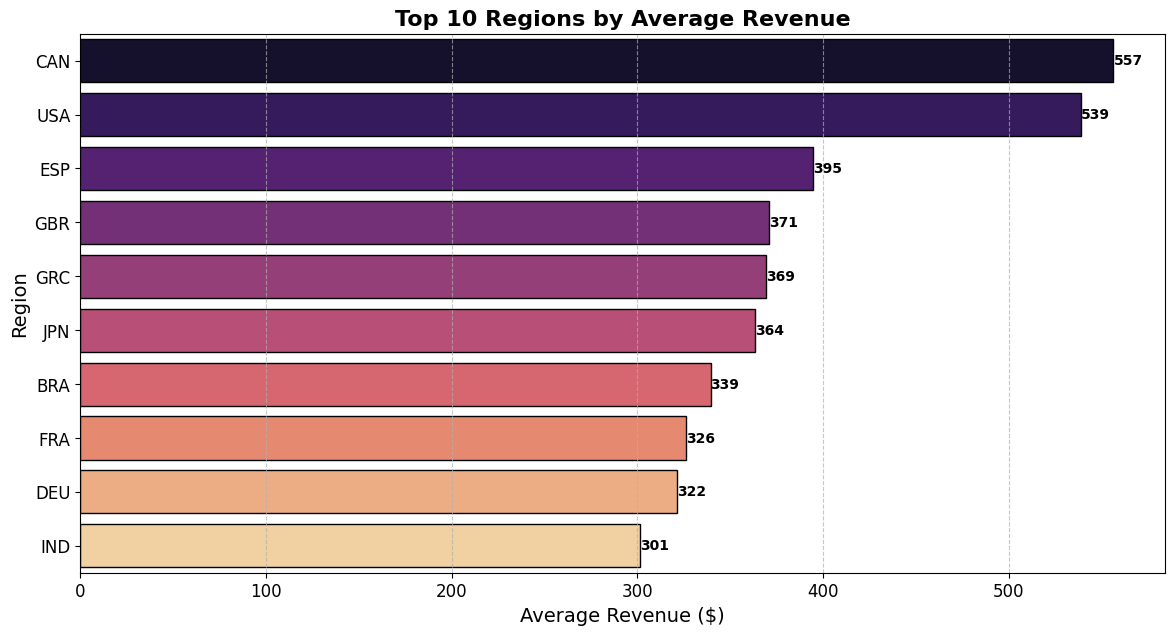

In [25]:
# Function to add value labels
def add_value_labels(ax):
    for p in ax.patches:
        ax.annotate(f'{p.get_width():,.0f}',  
                    (p.get_width(), p.get_y() + p.get_height() / 2),  
                    ha='left', va='center', fontsize=10, color='black', fontweight='bold')

# Customizing Bar Graph for Revenue by Language
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='revenue', y='language', data=lang_revenue.sort_values(by='revenue', ascending=False).head(10),
                 palette='viridis', edgecolor='black')

# Customizing appearance
plt.title('Top 10 Languages by Average Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Average Revenue ($)', fontsize=14)
plt.ylabel('Language', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
add_value_labels(ax)  # Adding value labels

plt.grid(axis='x', linestyle='--', alpha=0.7)  # Light grid for readability
plt.show()

# Customizing Bar Graph for Revenue by Region
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='revenue', y='region_iso3', data=region_revenue.sort_values(by='revenue', ascending=False).head(10),
                 palette='magma', edgecolor='black')

# Customizing appearance
plt.title('Top 10 Regions by Average Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Average Revenue ($)', fontsize=14)
plt.ylabel('Region', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
add_value_labels(ax)  # Adding value labels

plt.grid(axis='x', linestyle='--', alpha=0.7)  # Light grid for readability
plt.show()
